# Case studies

Five days, not a second evaluation. Notebook 05 already says holidays are worse on average. These days show *why*.

Same-day issued weather (Previous Runs lead 0), scored with the **day** model, plotted half-hourly.

`demand_lag_48` will be the top SHAP feature on every day. That is the model, not a finding. Tables below drop the lags so you can see the leftover (calendar / weather). The useful number is **lag gap**: actual minus yesterday.

A normal holdout weekday is already ~700 MW MAE (median). An "ordinary Tuesday" at ~800 MW is typical, not a clean success.

| Case | Date | What to look for |
|---|---|---|
| Median weekday | resolved from data | Control: closest to median weekday MAE. Holdout. |
| Summer bank holiday | 31 Aug 2026 | Demand drops. Weekly lag is a working Monday. Holdout. |
| Tuesday after | 1 Sep 2026 | Working day whose yesterday is the holiday. Holdout. |
| Clocks forward | 29 Mar 2026 | 46 settlement periods. In-sample — the holdout has no clock change. |
| Hottest holdout weekday | resolved from data | Weather leftover after lags. Holdout. |

COVID years are out of training and out of this notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.cases import (
    case_note,
    case_row,
    case_shap,
    shap_path,
    resolve_cases,
    score_same_day,
    slice_case,
    to_hourly,
    weekday_median_mae,
)
from energy_forecast.evaluate import overall_metrics
from energy_forecast.forecast import prepare_history
from energy_forecast.model import load_day_models

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

In [2]:
frame = prepare_history()
day_models = load_day_models()
holdout_start = day_models.metadata["holdout_start"]
scored = score_same_day(frame, day_models)
hourly = to_hourly(scored)
cases = resolve_cases(hourly, holdout_start)
baseline_mae = weekday_median_mae(hourly, holdout_start)
print("same-day rows", len(scored), "hourly", len(hourly))
print("holdout start", holdout_start)
print("weekday median daily MAE", round(baseline_mae, 1))
for case in cases:
    print(case.case_id, case.date)

same-day rows 47664 hourly 23832
holdout start 2026-07-25 23:30:00+01:00
weekday median daily MAE 705.8
control 2026-08-04
holiday 2026-08-31
after_holiday 2026-09-01
clock_change 2026-03-29
weather 2026-08-13


## Summary

MAE against the **median** holdout weekday. Positive *vs weekday* is extra error on top of a typical day (~700 MW). `lag_gap` is actual minus yesterday. Positive bias means the model was low.

,case,date,title,in_holdout,n,mae,vs_weekday,bias,coverage_80,demand_mw,lag_48,lag_gap,temperature_2m
0,control,2026-08-04,Median weekday,True,24,705.84,0.00,101.15,0.96,"24,109.35","22,413.77","1,695.58",21.31
1,holiday,2026-08-31,Summer bank holiday,True,24,958.51,252.68,-237.97,0.96,"20,877.38","21,257.75",-380.38,16.30
2,after_holiday,2026-09-01,Tuesday after the bank holiday,True,24,"1,198.42",492.58,80.99,0.58,"23,497.73","20,877.38","2,620.35",16.45
3,clock_change,2026-03-29,Clocks forward,False,23,521.76,-184.07,36.75,0.96,"25,886.50","23,152.13","2,734.37",7.13
4,weather,2026-08-13,Hottest holdout weekday,True,24,385.41,-320.43,164.87,0.83,"24,580.60","23,065.90","1,514.71",26.43


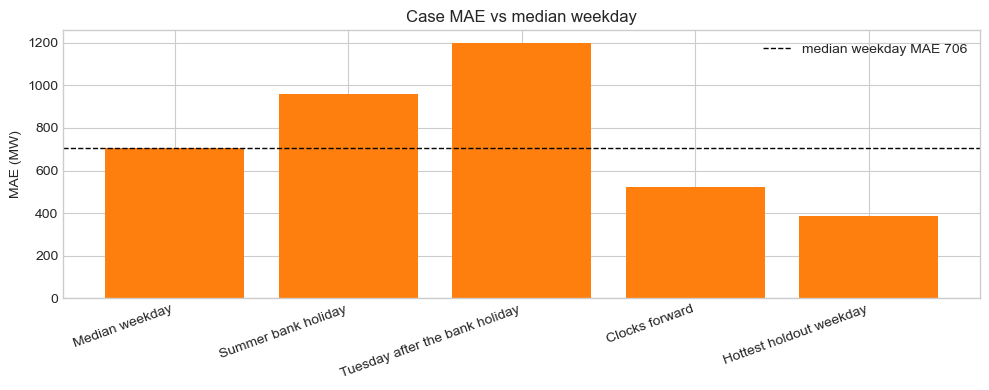

In [3]:
rows = []
hourly_by_case = {}
scored_by_case = {}
for case in cases:
    day_h = slice_case(hourly, case.date)
    day_s = slice_case(scored, case.date)
    hourly_by_case[case.case_id] = day_h
    scored_by_case[case.case_id] = day_s
    rows.append(case_row(case, day_h, baseline_mae))
summary = pd.DataFrame(rows)
display(summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary["title"], summary["mae"], color="tab:orange")
ax.axhline(baseline_mae, color="black", linestyle="--", linewidth=1, label=f"median weekday MAE {baseline_mae:,.0f}")
ax.set_ylabel("MAE (MW)")
ax.set_title("Case MAE vs median weekday")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Each day

Actual vs P50 and the band, then the day's metrics and mean SHAP (top five). One sentence under each plot is the only interpretation.

### Median weekday — 2026-08-04

Control: the holdout weekday whose MAE is closest to the median. ~700 MW is typical, not a success. **Holdout.**

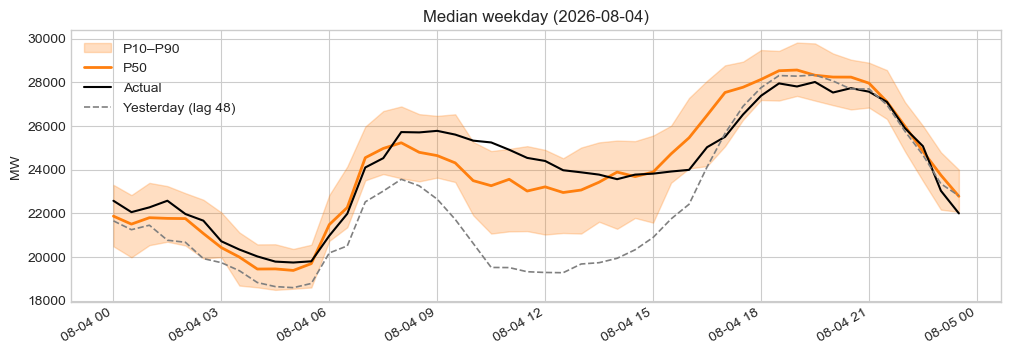

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,24,705.84,857.19,0.03,101.15,150.88,352.92,142.38,0.96,"2,837.67",0.55


Holdout: MAE 706 MW (+0 vs weekday median). Model ran low (bias +101). After lags, mean SHAP led by day_of_week. Demand vs yesterday +1,696 MW.
mean (lags dropped)


,feature,mean_abs_shap
0,day_of_week,662.53
1,settlement_period,406.99
2,period_sin,376.75
3,month_cos,340.85
4,wind_speed_10m,279.12


p10 (lags dropped)


,feature,mean_abs_shap
0,settlement_period,74.04
1,shortwave_radiation,68.98
2,cdd_sum_72h,54.70
3,month_cos,54.19
4,day_of_week,51.55


p90 (lags dropped)


,feature,mean_abs_shap
0,settlement_period,73.99
1,month_cos,65.32
2,day_of_week,63.05
3,period_cos,62.88
4,temp_mean_72h,54.08


### Summer bank holiday — 2026-08-31

Monday 31 Aug 2026. Demand drops. lag_336 is a working Monday, so the weekly lag pulls the level up. **Holdout.**

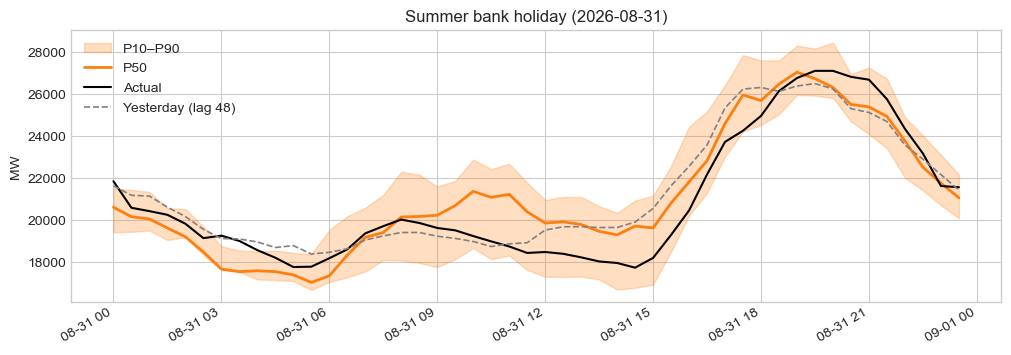

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,24,958.51,"1,121.63",0.05,-237.97,122.23,479.26,189.80,0.96,"2,919.81",0.55


Holdout: MAE 959 MW (+253 vs weekday median). Model ran high (bias -238). After lags, mean SHAP led by is_holiday. Demand vs yesterday -380 MW.
mean (lags dropped)


,feature,mean_abs_shap
0,is_holiday,"1,717.36"
1,day_of_week,944.04
2,period_sin,480.69
3,settlement_period,409.07
4,wind_speed_10m,400.36


p10 (lags dropped)


,feature,mean_abs_shap
0,is_holiday,129.13
1,settlement_period,90.44
2,cdd_sum_72h,85.21
3,wind_speed_10m,75.33
4,month_cos,59.74


p90 (lags dropped)


,feature,mean_abs_shap
0,settlement_period,85.70
1,day_of_week,81.71
2,period_cos,71.13
3,is_holiday,67.21
4,month_cos,62.45


### Tuesday after the bank holiday — 2026-09-01

1 Sep 2026. A working Tuesday whose lag_48 is the holiday. This is the case the holiday slice hides. **Holdout.**

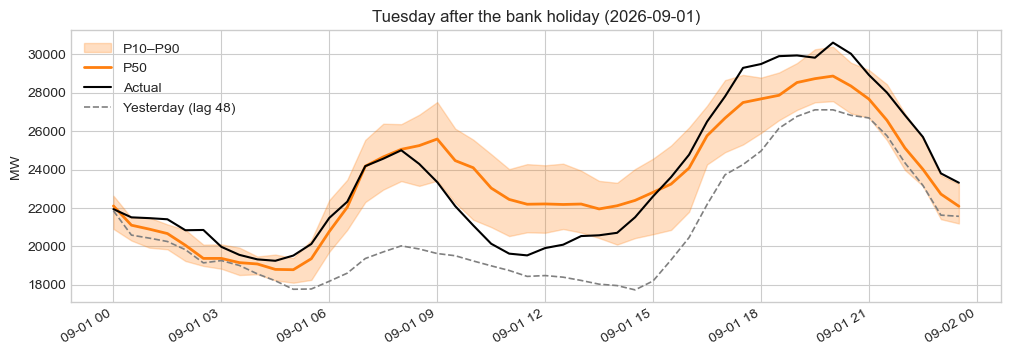

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,24,"1,198.42","1,444.45",0.05,80.99,257.41,599.21,197.93,0.58,"2,765.15",0.36


Holdout: MAE 1,198 MW (+493 vs weekday median). Model ran low (bias +81). After lags, mean SHAP led by day_of_week. Demand vs yesterday +2,620 MW.
mean (lags dropped)


,feature,mean_abs_shap
0,day_of_week,651.99
1,settlement_period,485.01
2,period_sin,374.38
3,period_cos,359.83
4,shortwave_radiation,289.72


p10 (lags dropped)


,feature,mean_abs_shap
0,settlement_period,86.01
1,month_sin,85.66
2,shortwave_radiation,63.72
3,day_of_week,59.13
4,cdd_sum_72h,56.41


p90 (lags dropped)


,feature,mean_abs_shap
0,settlement_period,163.27
1,day_of_week,74.42
2,period_cos,70.70
3,temp_mean_72h,49.21
4,month_cos,46.49


### Clocks forward — 2026-03-29

29 Mar 2026, last Sunday of March. 46 settlement periods. Calendar features can mis-align for a day. **In-sample.**

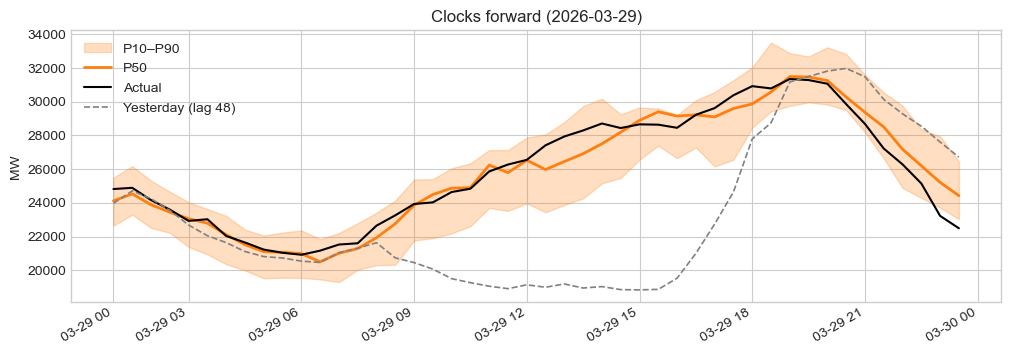

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,23,521.76,698.77,0.02,36.75,216.15,260.88,149.70,0.96,"3,435.36",0.66


In-sample: MAE 522 MW (-184 vs weekday median). Model ran low (bias +37). After lags, mean SHAP led by day_of_week. Demand vs yesterday +2,734 MW.
mean (lags dropped)


,feature,mean_abs_shap
0,day_of_week,935.45
1,period_sin,691.33
2,wind_speed_10m,666.01
3,settlement_period,432.75
4,month_cos,289.80


p10 (lags dropped)


,feature,mean_abs_shap
0,day_of_week,124.99
1,settlement_period,90.53
2,month_cos,80.22
3,wind_speed_10m,78.47
4,hdd_sum_24h,55.12


p90 (lags dropped)


,feature,mean_abs_shap
0,day_of_week,114.20
1,temp_mean_72h,107.90
2,period_sin,91.39
3,settlement_period,79.32
4,period_cos,76.24


### Hottest holdout weekday — 2026-08-13

The warmest working day in the day-model holdout. The one place weather features should move the mean. **Holdout.**

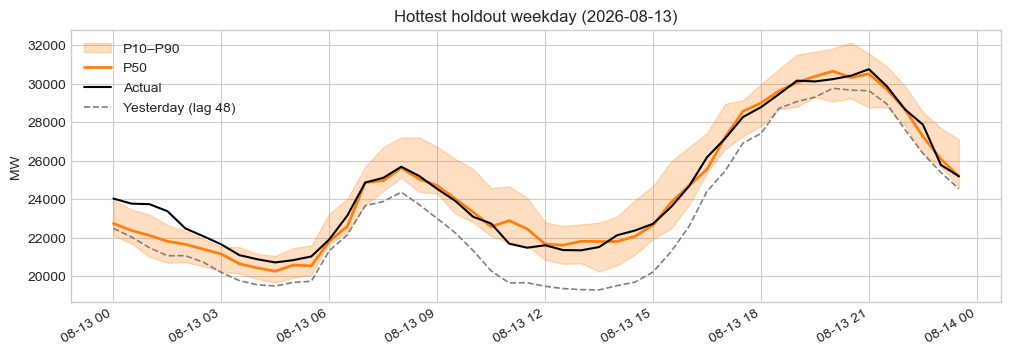

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,24,385.41,555.67,0.02,164.87,105.71,192.70,158.52,0.83,"2,196.47",0.82


Holdout: MAE 385 MW (-320 vs weekday median). Model ran low (bias +165). After lags, mean SHAP led by shortwave_radiation. Demand vs yesterday +1,515 MW.
mean (lags dropped)


,feature,mean_abs_shap
0,shortwave_radiation,661.91
1,cdd_sum_24h,528.01
2,wind_speed_10m,493.85
3,day_of_week,388.58
4,period_sin,353.89


p10 (lags dropped)


,feature,mean_abs_shap
0,shortwave_radiation,128.83
1,cdd_sum_24h,128.62
2,day_of_week,81.98
3,wind_speed_10m,81.79
4,settlement_period,72.02


p90 (lags dropped)


,feature,mean_abs_shap
0,month_cos,66.86
1,settlement_period,66.10
2,period_cos,58.15
3,day_of_week,53.15
4,temp_mean_fwd_24h,53.02


In [4]:
def plot_day(day, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    if day.empty:
        ax.set_title(f"{title}: no rows")
        plt.show()
        return
    ax.fill_between(day["timestamp"], day["p10"], day["p90"], color="tab:orange", alpha=0.25, label="P10–P90")
    ax.plot(day["timestamp"], day["p50"], color="tab:orange", linewidth=2, label="P50")
    if "demand_mw" in day.columns:
        ax.plot(day["timestamp"], day["demand_mw"], color="black", linewidth=1.5, label="Actual")
    if "demand_lag_48" in day.columns:
        ax.plot(day["timestamp"], day["demand_lag_48"], color="0.5", linestyle="--", linewidth=1.2, label="Yesterday (lag 48)")
    ax.set_title(title)
    ax.set_ylabel("MW")
    ax.legend()
    fig.autofmt_xdate()
    plt.show()

for case in cases:
    day_h = hourly_by_case[case.case_id]
    day_s = scored_by_case[case.case_id]
    display(Markdown(f"### {case.title} — {case.date}"))
    display(Markdown(case.why + (" **In-sample.**" if not case.in_holdout else " **Holdout.**")))
    plot_day(day_s.sort_values("timestamp"), f"{case.title} ({case.date})")
    if day_h.empty:
        print("No rows for this date.")
        continue
    display(overall_metrics(day_h))
    shap_tables = case_shap(day_s, day_models, n=5)
    print(case_note(case, day_h, baseline_mae, shap_tables))
    for output, table in shap_tables.items():
        print(output, "(lags dropped; shap_mw = MW added this day)")
        display(table)
    top = shap_tables["mean"]
    if not top.empty:
        feat = str(top["feature"].iloc[0])
        path = shap_path(day_s.sort_values("timestamp"), day_models, feat, "mean")
        if not path.empty:
            fig, ax = plt.subplots(figsize=(12, 3))
            ax.plot(path["timestamp"], path["shap_mw"], color="tab:green", linewidth=2, label="MW added to mean")
            ax.axhline(0, color="0.5", linewidth=0.8)
            ax.set_ylabel("SHAP (MW)")
            ax2 = ax.twinx()
            ax2.plot(path["timestamp"], path["value"], color="0.4", linestyle="--", linewidth=1.2, label=feat)
            ax2.set_ylabel(feat)
            ax.set_title(f"{feat}: value vs MW added to the mean")
            lines, labels = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines + lines2, labels + labels2, loc="best")
            fig.autofmt_xdate()
            plt.show()